# Gradious AI-Enhanced Cloud Storage Platform
## Machine Learning Module: File Classification & Suspicious Upload Detection

This notebook contains the end-to-end machine learning pipeline for:
1. **File Category Classifier**: Classifying files into `Document`, `Image`, `Video`, `Audio`, and `Code` using **Random Forest**.
2. **Suspicious Upload Anomaly Detector**: Identifying normal vs. suspicious/malicious upload behaviors based on metadata and user activity patterns using **Random Forest**.

---

### 1. Environment Setup & Library Imports

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

print("All Machine Learning dependencies imported successfully.")

All Machine Learning dependencies imported successfully.


--- 
## Part 1: File Category Classification Model (Random Forest)

### 1.1 Load File Classification Dataset

In [2]:
dataset_dir = Path("dataset")
train_path = dataset_dir / "train.csv"
test_path = dataset_dir / "test.csv"

if not train_path.exists():
    train_path = dataset_dir / "file_classification_reduced.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path) if test_path.exists() else None

print(f"Training dataset shape: {df_train.shape}")
if df_test is not None:
    print(f"Testing dataset shape: {df_test.shape}")

df_train.head()

Training dataset shape: (1193, 21)
Testing dataset shape: (299, 21)


,filename,relative_path,category,extension,mime_type,file_size_bytes,file_size_kb,file_size_mb,width,height,...,fps,codec,sample_rate,channels,page_count,text_length,line_count,character_count,comment_line_count,blank_line_count
0,2RE7KOL5KV5FFCUG6CYUVEFF4KIUZN2V.pdf,Pdf/2RE7KOL5KV5FFCUG6CYUVEFF4KIUZN2V.pdf,Document,pdf,application/pdf,555800,542.77,0.53,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,50000.0,NaN,NaN,NaN,NaN
1,Orders-With Nulls.docx,Docx/Docx/Orders-With Nulls.docx,Document,docx,application/vnd.openxmlformats-officedocument....,92635,90.46,0.09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,92635.0,NaN,NaN,NaN,NaN
2,video_033.mp4,Video/video_033.mp4,Video,mp4,video/mp4,2240519,2188.01,2.14,1920.0,1036.0,...,24.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,153477552.cpp,code/1468/H/153477552.cpp,Code,cpp,text/x-c++,747,0.73,0.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,77.0,709.0,3.0,38.0
4,Screenshot (447).png,images/Screenshot (447).png,Image,png,image/png,66613,65.05,0.06,1920.0,1080.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Feature Engineering & Pipeline Construction

In [3]:
target_col = "category"
drop_cols = [c for c in ["filename", "relative_path", target_col] if c in df_train.columns]

X_train = df_train.drop(columns=drop_cols)
y_train = df_train[target_col]

if df_test is not None:
    X_test = df_test.drop(columns=drop_cols)
    y_test = df_test[target_col]
else:
    X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, random_state=42, test_size=0.2, stratify=y_train)

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

print("File Category Pipeline constructed successfully.")

File Category Pipeline constructed successfully.


C:\Users\Merlin\AppData\Local\Temp\ipykernel_4648\756751446.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()


### 1.3 Model Training & Performance Evaluation

In [4]:
clf_pipeline.fit(X_train, y_train)
y_pred = clf_pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"File Classification Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

File Classification Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

       Audio       1.00      1.00      1.00        50
        Code       1.00      1.00      1.00       100
    Document       1.00      1.00      1.00       100
       Image       1.00      1.00      1.00        29
       Video       1.00      1.00      1.00        20

    accuracy                           1.00       299
   macro avg       1.00      1.00      1.00       299
weighted avg       1.00      1.00      1.00       299



### 1.4 Confusion Matrix Visualization

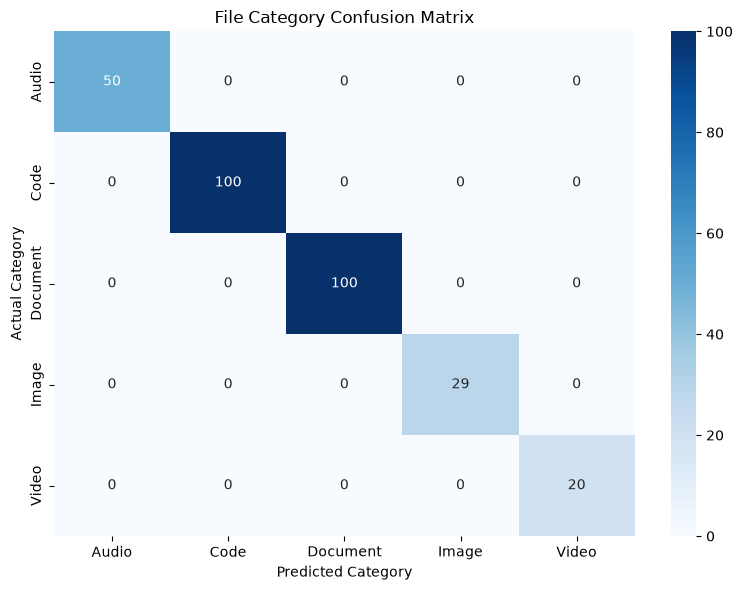

In [5]:
cm = confusion_matrix(y_test, y_pred, labels=clf_pipeline.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=clf_pipeline.classes_, yticklabels=clf_pipeline.classes_)
plt.title("File Category Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.tight_layout()
plt.show()

--- 
## Part 2: Suspicious Upload Anomaly Detection Model (Random Forest)

### 2.1 Load Behavioral Metadata Dataset

In [6]:
susp_train_path = dataset_dir / "suspicious_upload_train_v2.csv"
susp_test_path = dataset_dir / "suspicious_upload_test_v2.csv"

if not susp_train_path.exists():
    susp_train_path = dataset_dir / "suspicious_upload_dataset_v2.csv"

df_susp_train = pd.read_csv(susp_train_path)
df_susp_test = pd.read_csv(susp_test_path) if susp_test_path.exists() else None

print(f"Suspicious Upload Training shape: {df_susp_train.shape}")
df_susp_train.head()

Suspicious Upload Training shape: (2400, 10)


,file_size_mb,file_extension,upload_frequency,uploads_last_hour,uploads_last_24h,user_file_count,access_count,unique_ip_count,account_age_days,label
0,1.63,docx,4.80,0,4,94,6,1,199,Normal
1,392.78,mp4,13.05,5,20,169,10,1,332,Normal
2,39.27,csv,24.67,25,63,624,18,1,306,Normal
3,3.78,jpg,2.92,2,7,190,4,1,94,Normal
4,34.11,py,13.34,2,12,74,10,2,92,Suspicious


### 2.2 Preprocessing & Random Forest Classifier Training

In [7]:
susp_target = "label" if "label" in df_susp_train.columns else "is_suspicious"
susp_drop = [c for c in ["upload_id", "filename", "user_id", "upload_timestamp", susp_target] if c in df_susp_train.columns]

X_susp_train = df_susp_train.drop(columns=susp_drop)
y_susp_train = df_susp_train[susp_target]

if df_susp_test is not None:
    X_susp_test = df_susp_test.drop(columns=susp_drop)
    y_susp_test = df_susp_test[susp_target]
else:
    X_susp_train, X_susp_test, y_susp_train, y_susp_test = train_test_split(X_susp_train, y_susp_train, test_size=0.2, random_state=42, stratify=y_susp_train)

susp_num_features = X_susp_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
susp_cat_features = X_susp_train.select_dtypes(include=["object"]).columns.tolist()

susp_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), susp_num_features),
    ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="constant", fill_value="unknown")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), susp_cat_features)
])

susp_pipeline = Pipeline(steps=[
    ("preprocessor", susp_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

susp_pipeline.fit(X_susp_train, y_susp_train)
y_susp_pred = susp_pipeline.predict(X_susp_test)

susp_acc = accuracy_score(y_susp_test, y_susp_pred)
print(f"Suspicious Upload Detection Accuracy: {susp_acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_susp_test, y_susp_pred))

C:\Users\Merlin\AppData\Local\Temp\ipykernel_4648\323299659.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  susp_cat_features = X_susp_train.select_dtypes(include=["object"]).columns.tolist()


Suspicious Upload Detection Accuracy: 99.00%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       510
  Suspicious       1.00      0.93      0.97        90

    accuracy                           0.99       600
   macro avg       0.99      0.97      0.98       600
weighted avg       0.99      0.99      0.99       600



### 2.3 Confusion Matrix Visualization

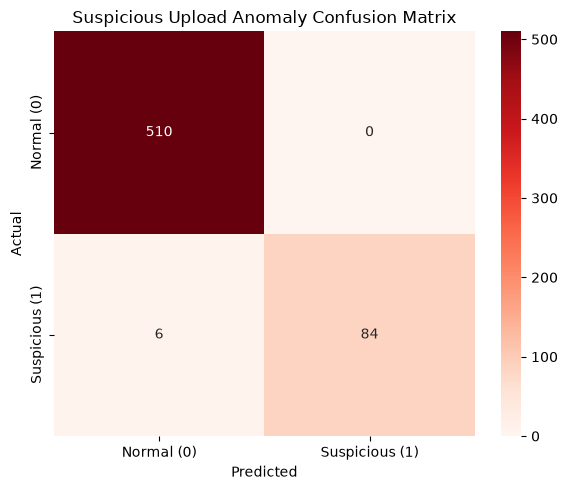

In [8]:
susp_cm = confusion_matrix(y_susp_test, y_susp_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(susp_cm, annot=True, fmt="d", cmap="Reds", xticklabels=["Normal (0)", "Suspicious (1)"], yticklabels=["Normal (0)", "Suspicious (1)"])
plt.title("Suspicious Upload Anomaly Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

--- 
## Part 3: Model Serialization & Export

Save trained Random Forest pipelines using `joblib` for backend inference.

In [9]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

joblib.dump(clf_pipeline, models_dir / "file_classifier_random_forest.joblib")
joblib.dump(susp_pipeline, models_dir / "suspicious_upload_random_forest_v2.joblib")

print("Both Random Forest models successfully serialized to models/")

Both Random Forest models successfully serialized to models/
